In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

In [3]:
def p2(x):
    return (3 * x) + 1

In [5]:
print(p2(4))

13


In [6]:
mango_data = pd.read_csv("../dx601-homework-03/mango-tiny.tsv", sep="\t")

In [7]:
mango_data

,green_rating,yellow_rating,softness,wrinkles,estimated_flavor,estimated_sweetness,rated_flavor
0,1,5,4,0,4,4,5
1,1,5,5,1,5,5,1
2,2,4,3,1,3,3,3
3,3,3,2,0,2,1,2
4,5,1,1,1,1,1,1
5,4,2,1,1,1,1,1
6,5,1,1,1,2,1,1
7,3,3,2,1,2,2,2


Text(0.5, 1.0, 'Rated Flavor vs Estimated Sweetness')

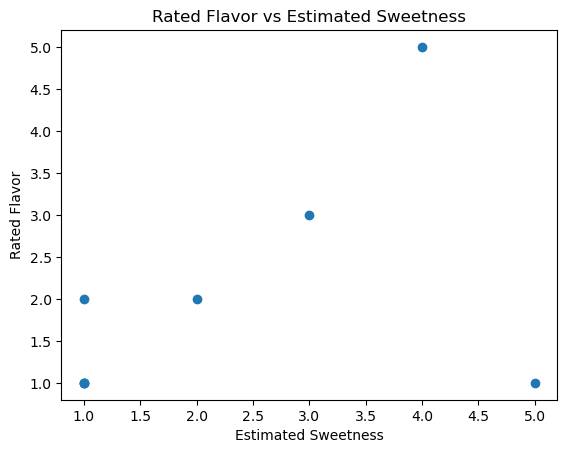

In [8]:
p3 = plt.scatter(mango_data["estimated_sweetness"], mango_data["rated_flavor"])

plt.xlabel("Estimated Sweetness")
plt.ylabel("Rated Flavor")
plt.title("Rated Flavor vs Estimated Sweetness")

In [11]:
def f4(df):
    # the rename here is not strictly necessary, but makes the output more clear below.
    # without the rename, the column below would be called estimated_sweetness.
    return df["estimated_sweetness"].rename("prediction")




In [14]:
# understand diffrence between series and dataframe
# Using df["column_name"] returns a Series.
# Using df[["column_name"]] (note the double brackets) returns a DataFrame with one column.
single_series = mango_data["estimated_sweetness"] 
print(type(single_series))  # <class 'pandas.core.series.Series'>

single_df = mango_data[["estimated_sweetness"]]  
print(type(single_df))  # <class 'pandas.core.frame.DataFrame'>

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [16]:
predicted_single_series = f4(mango_data)
p4 = mango_data["rated_flavor"] - predicted_single_series

In [17]:
#Estimating loss using funtion
def f5(df):
    return 0.8 * df["yellow_rating"] + 0.2 * df["softness"]

prediction_using_f5 = f5(mango_data)
# Set p5 to be the 
# loss of each row of data after using f5 to predict the rated flavor column. 
# The result should be a sequence of losses, not a single number.
p5 = mango_data["rated_flavor"] - prediction_using_f5



In [18]:
'''
Your calculation p5 = actual - predicted gives you the residuals (signed errors) per row.
Residuals are a valid summary of "loss" if the use case expects signed errors.
If you want a strictly positive loss measure (typical in many ML tasks), transform residuals using absolute value or square.
'''
p5 = abs(mango_data["rated_flavor"] - prediction_using_f5)
p5 = (mango_data["rated_flavor"] - prediction_using_f5) ** 2

In [20]:
def f6(df):
    return 1.2 * df["yellow_rating"] - 0.1 * df["green_rating"] - 0.1 * df["wrinkles"]

prediction_using_f6 = f6(mango_data)
# Set p6 to be the average 
# loss using f6 to predict the rated flavor column.
p6 = np.mean(abs(mango_data["rated_flavor"] - prediction_using_f6))

In [28]:
from sklearn.linear_model import LinearRegression
model_mango = LinearRegression()


# Build a linear regression for the mango rated flavor column using just the estimated 
# flavor column. Set p11 to the prediction of this model when the estimated flavor value is 3.

# Step 1: Set X_mango and Y_mango
X_mango = mango_data[["estimated_flavor"]] # dataframe
print(X_mango.shape)
Y_mango = mango_data["rated_flavor"] #series
print(Y_mango.shape)

# Step 2: Create and fit the model
model_mango = LinearRegression()
model_mango.fit(X_mango, Y_mango)

# Step 3: Predit the extimated_flavor = 3 
p11 = model_mango.predict(pd.DataFrame({"estimated_flavor": [3]}))[0] # predict expects a 2d array, output is array
print("Prediction when estimated_flavor=3: ", p11)

(8, 1)
(8,)
Prediction when estimated_flavor=3:  2.2142857142857144


### What is the additive constant in a linear regression?
The additive constant (also called the intercept, or bias term) is the value where the regression line crosses the y-axis when all the input features are zero.

### In the linear regression equation:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

$\hat{y}$ = predicted value
$\beta_0$ = intercept (additive constant)
$\beta_1, \beta_2, \ldots, \beta_p$ = coefficients (weights) for features $x_1, x_2, \ldots, x_p$


### Why is the additive constant important?


### Baseline prediction:
The additive constant represents the predicted value when all features are zero. It defines the baseline level of the output.


### Model flexibility:
It allows the regression line (or hyperplane) to shift up or down to better fit the data. Without an intercept, the regression line would be forced to pass through the origin (0,0), which often is not realistic.


### Improved accuracy:
By including the additive constant, the model can capture the average behavior of the target independent of features, thus typically improving prediction accuracy.

In [29]:
# Step1: Set X_mango and y_mango
X_mango = mango_data[["yellow_rating"]] # dataframe
y_mango = mango_data["rated_flavor"] # series

# Build a linear regression for the mango rated flavor column using just the yellow 
# rating column. Set p12 to the additive constant in the linear equation.

# Step2: fit the model
maango_linear_model = LinearRegression()
maango_linear_model.fit(X_mango, y_mango)

# Ste3: get the constant
p12 = maango_linear_model.intercept_

print(p12)

0.33333333333333304


### What is the coefficient in linear regression?
The coefficient (or weight) in linear regression represents how much the target variable (what you're trying to predict) is expected to change when the corresponding feature (input variable) increases by 1 unit, assuming all other features stay the same.

### Why are coefficients important?
Interpretation:

Coefficients help you understand how each input feature affects the prediction.

If the coefficient is positive, increasing that feature tends to increase the predicted value.
If it’s negative, increasing that feature tends to decrease the predicted value.
Model insight:

They reveal which features are most influential in predicting the target.

Prediction:

The coefficients are multiplied by feature values to compute predictions.

### How to calculate R-squared?
The R-squared value measures the proportion of variance in the dependent variable (rated_flavor) that is predictable from the independent variables (or from the predictions).
The formula for R-squared is:
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

$y_i$ = actual values (your rated_flavor) \
$\hat{y}_i$ = predicted values (prediction) \
$\bar{y}$ = mean of actual values

In [31]:
def f18(df):
    return 0.7 * df["estimated_flavor"]

prediction = f18(mango_data)
y_true = mango_data["rated_flavor"]
y_pred = prediction

ss_res = np.sum((y_true - y_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) # Total sum of squares

p18 = 1 - (ss_res/ss_tot)
print("R-squared: ", p18)

R-squared:  0.07428571428571418


In [32]:
def f6(df):
    return (1.2 * df["yellow_rating"]) - (0.1 * df["green_rating"]) - (0.1 * df["wrinkles"])

prediction_using_f6 = f6(mango_data)
p6 = np.mean((mango_data["rated_flavor"] - prediction_using_f6) **2 )

In [ ]:
def p7(df):
    return df["estimated_flavor"]

p7_prediction = p7(mango_data)
# Set p8 to be the average 
# loss using the "yellow_rating" column to predict the "rated_flavor" column as in Problem 3.
'''
“Set p8 to be the average loss using the yellow_rating column to predict the rated_flavor column as in Problem 3.”
So the predictor should be yellow_rating, and the target should be rated_flavor.
estimated_flavor doesn’t come into play here at all.
'''
p8 = np.mean((mango_data["rated_flavor"] - mango_data["yellow_rating"]) ** 2)